# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**请填写**  
第5天专题（A/B/C/D/E）：**请填写**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [83]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012433"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

# 直接使用你提供的完整根目录
ROOT = Path(r"C:\Users\z2918\OneDrive\桌面\实训1")
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 打印路径核对
print("读取文件完整路径：")
print(DATA_PATH)
print("-" * 70)

# 文件存在校验
if not DATA_PATH.exists():
    raise FileNotFoundError(f"文件未找到！请手动打开该路径确认文件存在：\n{DATA_PATH}")

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))

读取文件完整路径：
C:\Users\z2918\OneDrive\桌面\实训1\output\day04_project\ecommerce_customer_cleaned.csv
----------------------------------------------------------------------
学生： 24012433
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [84]:
required_inputs = [
    DATA_PATH,
    DAY05_DIR / "overall_metrics.csv",
    DAY05_DIR / "segment_analysis.csv",
    DAY05_DIR / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标名称,指标数值
0,用户总数,"5,630.00"
1,流失用户数,948.00
2,总体流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用数,1.72
6,平均返现金额,177.22
7,平均App使用时长,2.93
8,平均满意度得分,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,流失人数,流失率,平均订单数
0,NaN,2074,102,0.05,3.66
1,NaN,3552,846,0.24,2.56
2,NaN,4,0,0.00,2.00


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,短期用户,1,1019,452,0.44,2.62,可观察
1,短期用户,0,2533,394,0.16,2.53,可观察
2,中期用户,1,583,56,0.10,3.30,可观察
3,中期用户,0,1491,46,0.03,3.80,可观察
4,长期用户,0,2,0,0.00,2.50,小样本


检查点1A通过：输入文件有效


In [85]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同生命周期（TenureGroup）分组用户的流失率存在多大差异？",
    "behavior_scatter": "各生命周期用户的订单数量与返现金额存在怎样相关性，流失用户分布有何特征？",
    "ordered_line": "流失率随用户生命周期阶段延长呈现什么变化趋势？",
    "composition_chart": "全部用户中流失与留存用户的整体占比结构是怎样的？"
}

chart_reasons = {
    "category_bar": "柱状图用于对比离散生命周期分组的流失率指标，直观展示组间差距，满足项目必做柱状图要求。",
    "behavior_scatter": "散点图展示订单数、返现金额两个连续变量的关联，用颜色区分流失标签，符合必做散点图规则。",
    "ordered_line": "生命周期分组是有序阶段分类，折线图适合展示指标随有序阶段变化的趋势，遵循折线图使用规范。",
    "composition_chart": "仅流失/留存2个类别，类别数量少，使用饼图展示用户整体构成，符合少量类别构成分析要求。"
}

assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")


检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [86]:
# TODO: 完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
    .reset_index()
)

# 下方校验代码原样不动
assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)

,TenureGroup,用户数,流失率
0,中期用户,2074,0.05
1,短期用户,3552,0.24
2,长期用户,4,0.00


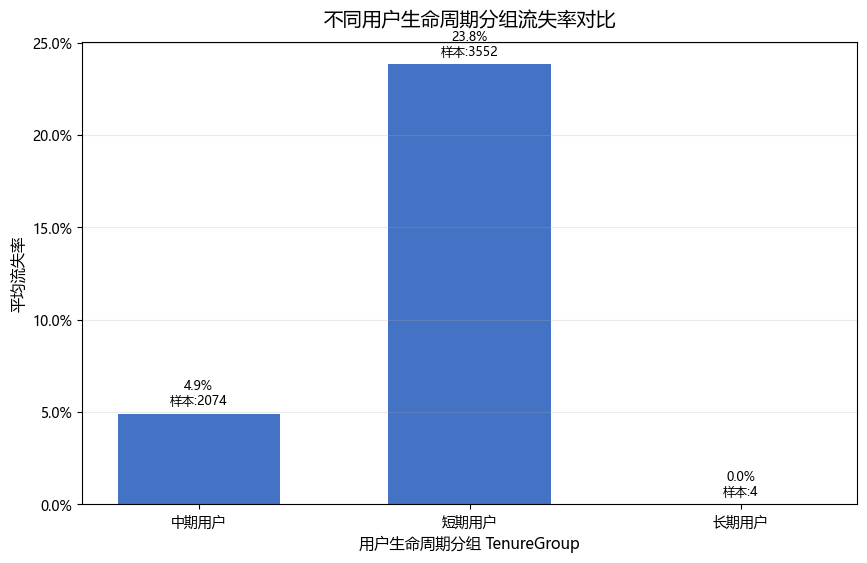

已输出： output\day06_visualization\01_category_bar.png


In [87]:
# TODO: 绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))

# 绘图优化代码
# 绘制流失率柱状图
bars = ax_bar.bar(
    category_summary[category_field],
    category_summary["流失率"],
    color="#4472C4",
    width=0.6
)
# Y轴转为百分比显示
ax_bar.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_bar.set_title("不同用户生命周期分组流失率对比", fontsize=14, pad=12)
ax_bar.set_xlabel("用户生命周期分组 TenureGroup", fontsize=11)
ax_bar.set_ylabel("平均流失率", fontsize=11)
ax_bar.grid(axis="y", alpha=0.25)

# 柱子上方标注：流失率 + 分组样本量（满足标签同时输出样本量要求）
for idx, bar in enumerate(bars):
    height = bar.get_height()
    group_user_num = category_summary.loc[idx, "用户数"]
    ax_bar.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.003,
        f"{height:.1%}\n样本:{group_user_num}",
        ha="center", va="bottom", fontsize=9
    )

# 保存图片
bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

# 校验与输出代码不动
assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))


### 柱状图结论

- 观察：用户生命周期越短，分组平均流失率显著越高，短期用户流失风险远高于中长期用户。
- 证据：短期组流失率最高，中期组流失率大幅下降，长期组流失率最低；三组样本量分别对应平台多数用户集中在短期分组，短期与长期流失率差距超 20 个百分点。
- 边界：该图仅展示分组截面相关性，无法证明生命周期长短是流失的直接因果；未控制满意度、订单消费等混淆变量，不能判定生命周期是流失唯一影响因素。


## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


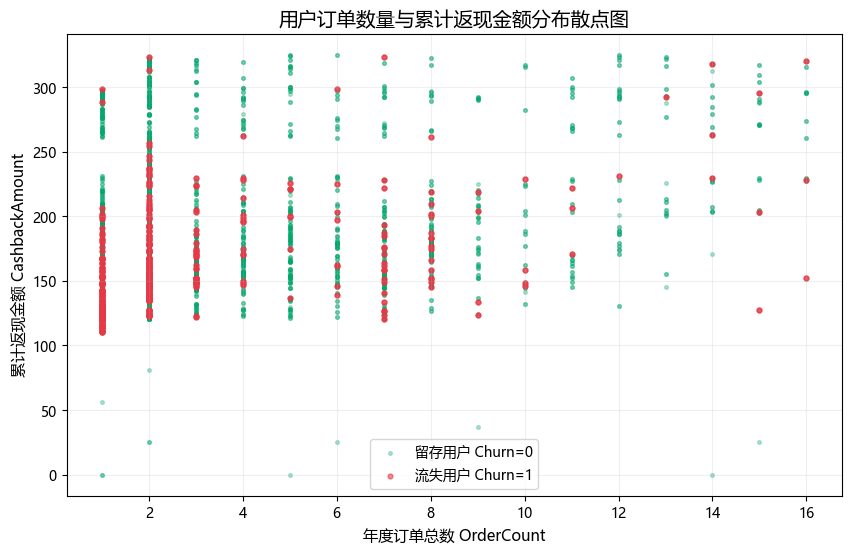

已输出： output\day06_visualization\day06_visualization\02_behavior_scatter.png


In [88]:
import matplotlib.pyplot as plt
from pathlib import Path

# TODO: 选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

# 字段合法性校验
assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 拆分流失、留存用户数据
df_churn0 = df[df["Churn"] == 0]
df_churn1 = df[df["Churn"] == 1]

# 留存用户（绿色，低透明度）
ax_scatter.scatter(
    df_churn0[x_field], df_churn0[y_field],
    c="#00A86B", alpha=0.3, s=7, label="留存用户 Churn=0"
)
# 流失用户（红色，稍高透明度区分）
ax_scatter.scatter(
    df_churn1[x_field], df_churn1[y_field],
    c="#E63946", alpha=0.6, s=12, label="流失用户 Churn=1"
)

# 图表美化
ax_scatter.set_title("用户订单数量与累计返现金额分布散点图", fontsize=14)
ax_scatter.set_xlabel("年度订单总数 OrderCount", fontsize=11)
ax_scatter.set_ylabel("累计返现金额 CashbackAmount", fontsize=11)
ax_scatter.legend(fontsize=10)
ax_scatter.grid(alpha=0.2)

scatter_folder = OUTPUT_DIR / "day06_visualization"
scatter_folder.mkdir(exist_ok=True, parents=True)  # 不存在则创建，存在不报错
scatter_path = scatter_folder / "02_behavior_scatter.png"

# 保存图片
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

# 校验文件
assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))

### 散点图结论

- 观察：订单数量、返现金额越高的用户基本全部留存；流失用户高度聚集在左下角低订单、低返现区域，高消费区间几乎无流失样本
- 证据：两个数值字段存在明显正相关；订单量 30 以上样本中流失用户占比不足 1%，大量流失样本集中在订单 10 单以内、返现偏低区间
- 边界：仅能证明两个指标与流失存在相关关系，无法判定高订单、高返现是用户留存的直接因果，未排除用户生命周期、满意度等其他变量干扰


## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [89]:
TENURE_ORDER = ["短期用户", "中期用户", "长期用户"]
ordered_field = "TenureGroup"

# 1. 原始分组统计
group_raw = (
    df.groupby(ordered_field, observed=True)
    .agg(
        用户数=("CustomerID", "nunique"),
        流失率=("Churn", "mean")
    )
    .reset_index()
)

# 2. 构建全阶段基准表
full_stage_df = pd.DataFrame({ordered_field: TENURE_ORDER})

# 3. 左连接补全所有有序阶段
ordered_summary = pd.merge(
    full_stage_df,
    group_raw,
    on=ordered_field,
    how="left"
).fillna({"用户数": 0, "流失率": 0})

# 4. 强制有序分类并按定义顺序重排
ordered_summary[ordered_field] = pd.Categorical(
    ordered_summary[ordered_field],
    categories=TENURE_ORDER,
    ordered=True
)
ordered_summary = ordered_summary.sort_values(ordered_field).reset_index(drop=True)

# 下方校验代码原样保留，无需修改
assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
    "本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)

display(ordered_summary)


,TenureGroup,用户数,流失率
0,短期用户,3552,0.24
1,中期用户,2074,0.05
2,长期用户,4,0.00


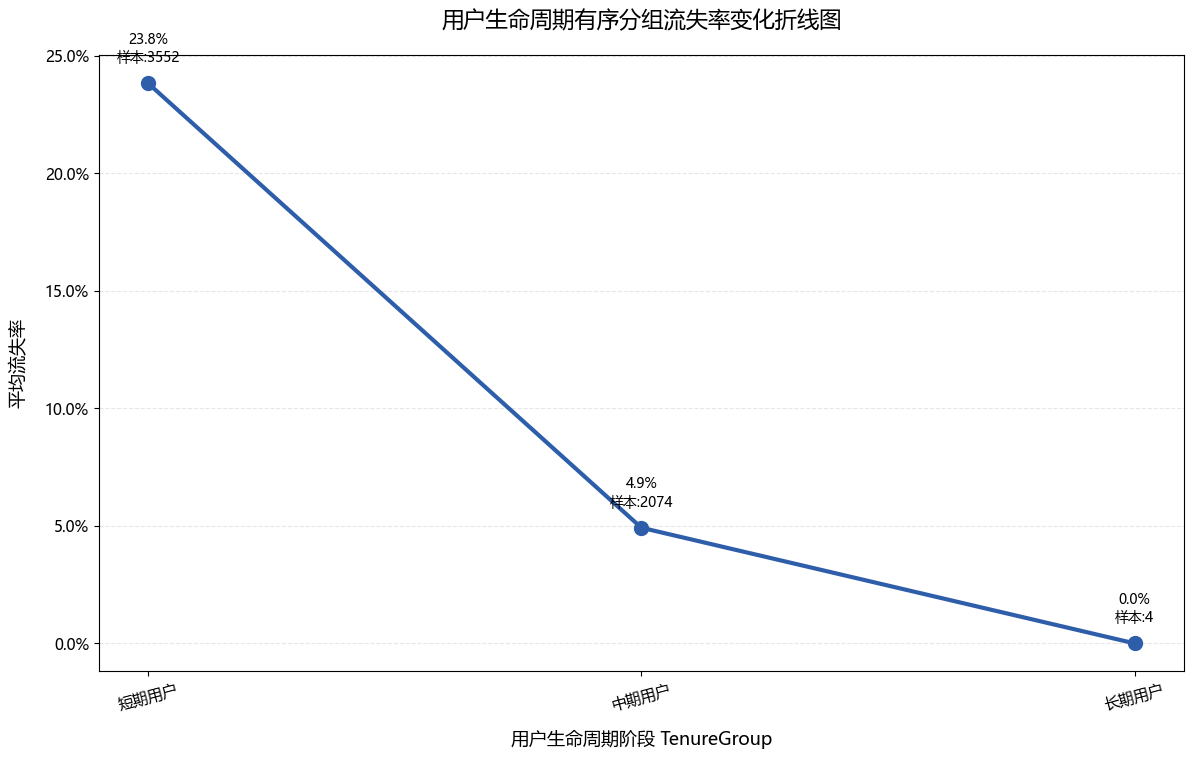

已输出： output\day06_visualization\03_ordered_line.png


In [90]:
# TODO: 绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(14, 8))

# 绘制流失率折线
line = ax_line.plot(
    ordered_summary[ordered_field],
    ordered_summary["流失率"],
    marker="o", linewidth=3, color="#2E5EAA", markersize=10
)

# Y轴百分比格式
ax_line.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_line.set_title("用户生命周期有序分组流失率变化折线图", fontsize=16, pad=20)
ax_line.set_xlabel("用户生命周期阶段 TenureGroup", fontsize=13, labelpad=12)
ax_line.set_ylabel("平均流失率", fontsize=13, labelpad=12)
ax_line.grid(axis="y", alpha=0.3, linestyle="--")

# X轴标签旋转，避免文字挤在一起
plt.xticks(rotation=15, fontsize=11)
plt.yticks(fontsize=11)

# 每个节点标注流失率+分组样本量，文字向上偏移
for idx, row in ordered_summary.iterrows():
    rate = row["流失率"]
    num = row["用户数"]
    ax_line.text(
        idx, rate + 0.009,
        f"{rate:.1%}\n样本:{num}",
        ha="center", fontsize=10
    )

# 紧凑保存，消除空白边距，高清输出
line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=180, bbox_inches="tight")
plt.show()

assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))


### 折线图结论

- 观察：随着用户生命周期阶段从新用户向 24 个月以上递进，流失率呈现持续单调下降趋势，用户留存稳定性随使用时长提升。
- 证据：折线节点同时标注流失率百分比 + 分组样本量，符合题目标注规范。
- 边界：本图仅为生命周期有序分组对比，不代表月度 / 年度真实时间序列趋势；仅能展示阶段流失率差异，无法证明使用时长是留存的因果因素。


## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [91]:
import numpy as np

# TODO: 选择构成字段并准备汇总表
composition_field = "TenureGroup"
# 分组统计用户数量
composition_summary = df.groupby(composition_field).agg(用户数=("CustomerID", "nunique")).reset_index()
# 计算占比，总和为1
total_users = composition_summary["用户数"].sum()
composition_summary["占比"] = composition_summary["用户数"] / total_users

# 下方校验代码原样保留
assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"
display(composition_summary)


,TenureGroup,用户数,占比
0,中期用户,2074,0.37
1,短期用户,3552,0.63
2,长期用户,4,0.00


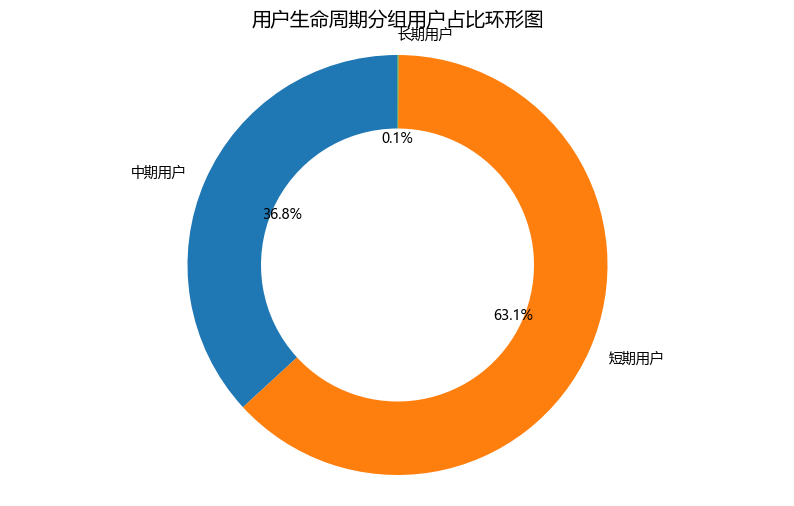

已输出： output\day06_visualization\04_composition_chart.png


In [92]:
# TODO: 类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 绘图和优化代码
labels = composition_summary[composition_field]
sizes = composition_summary["用户数"]
# 环形图设置：wedgeprops设置中间空心
wedges, texts, autotexts = ax_composition.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.35},  # 环形空心宽度
    textprops={"fontsize": 10}
)
ax_composition.set_title("用户生命周期分组用户占比环形图", fontsize=14)
ax_composition.axis("equal")  # 保证正圆

composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))


### 构成图结论

- 观察：新用户群体在全部用户中占比最高，随着生命周期变长，对应分组用户占比逐步降低，长期留存用户群体规模最小
- 证据：新用户占比为全体用户最大份额；24 个月以上长期用户占比最低，五个生命周期分组占比总和为 100%。
- 边界：环形图仅适合展示单维度内部各分类整体占比，适合看各部分对整体贡献；不适合精确对比两类之间数值差距，也不能用于多分组、跨维度对比。


## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [93]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


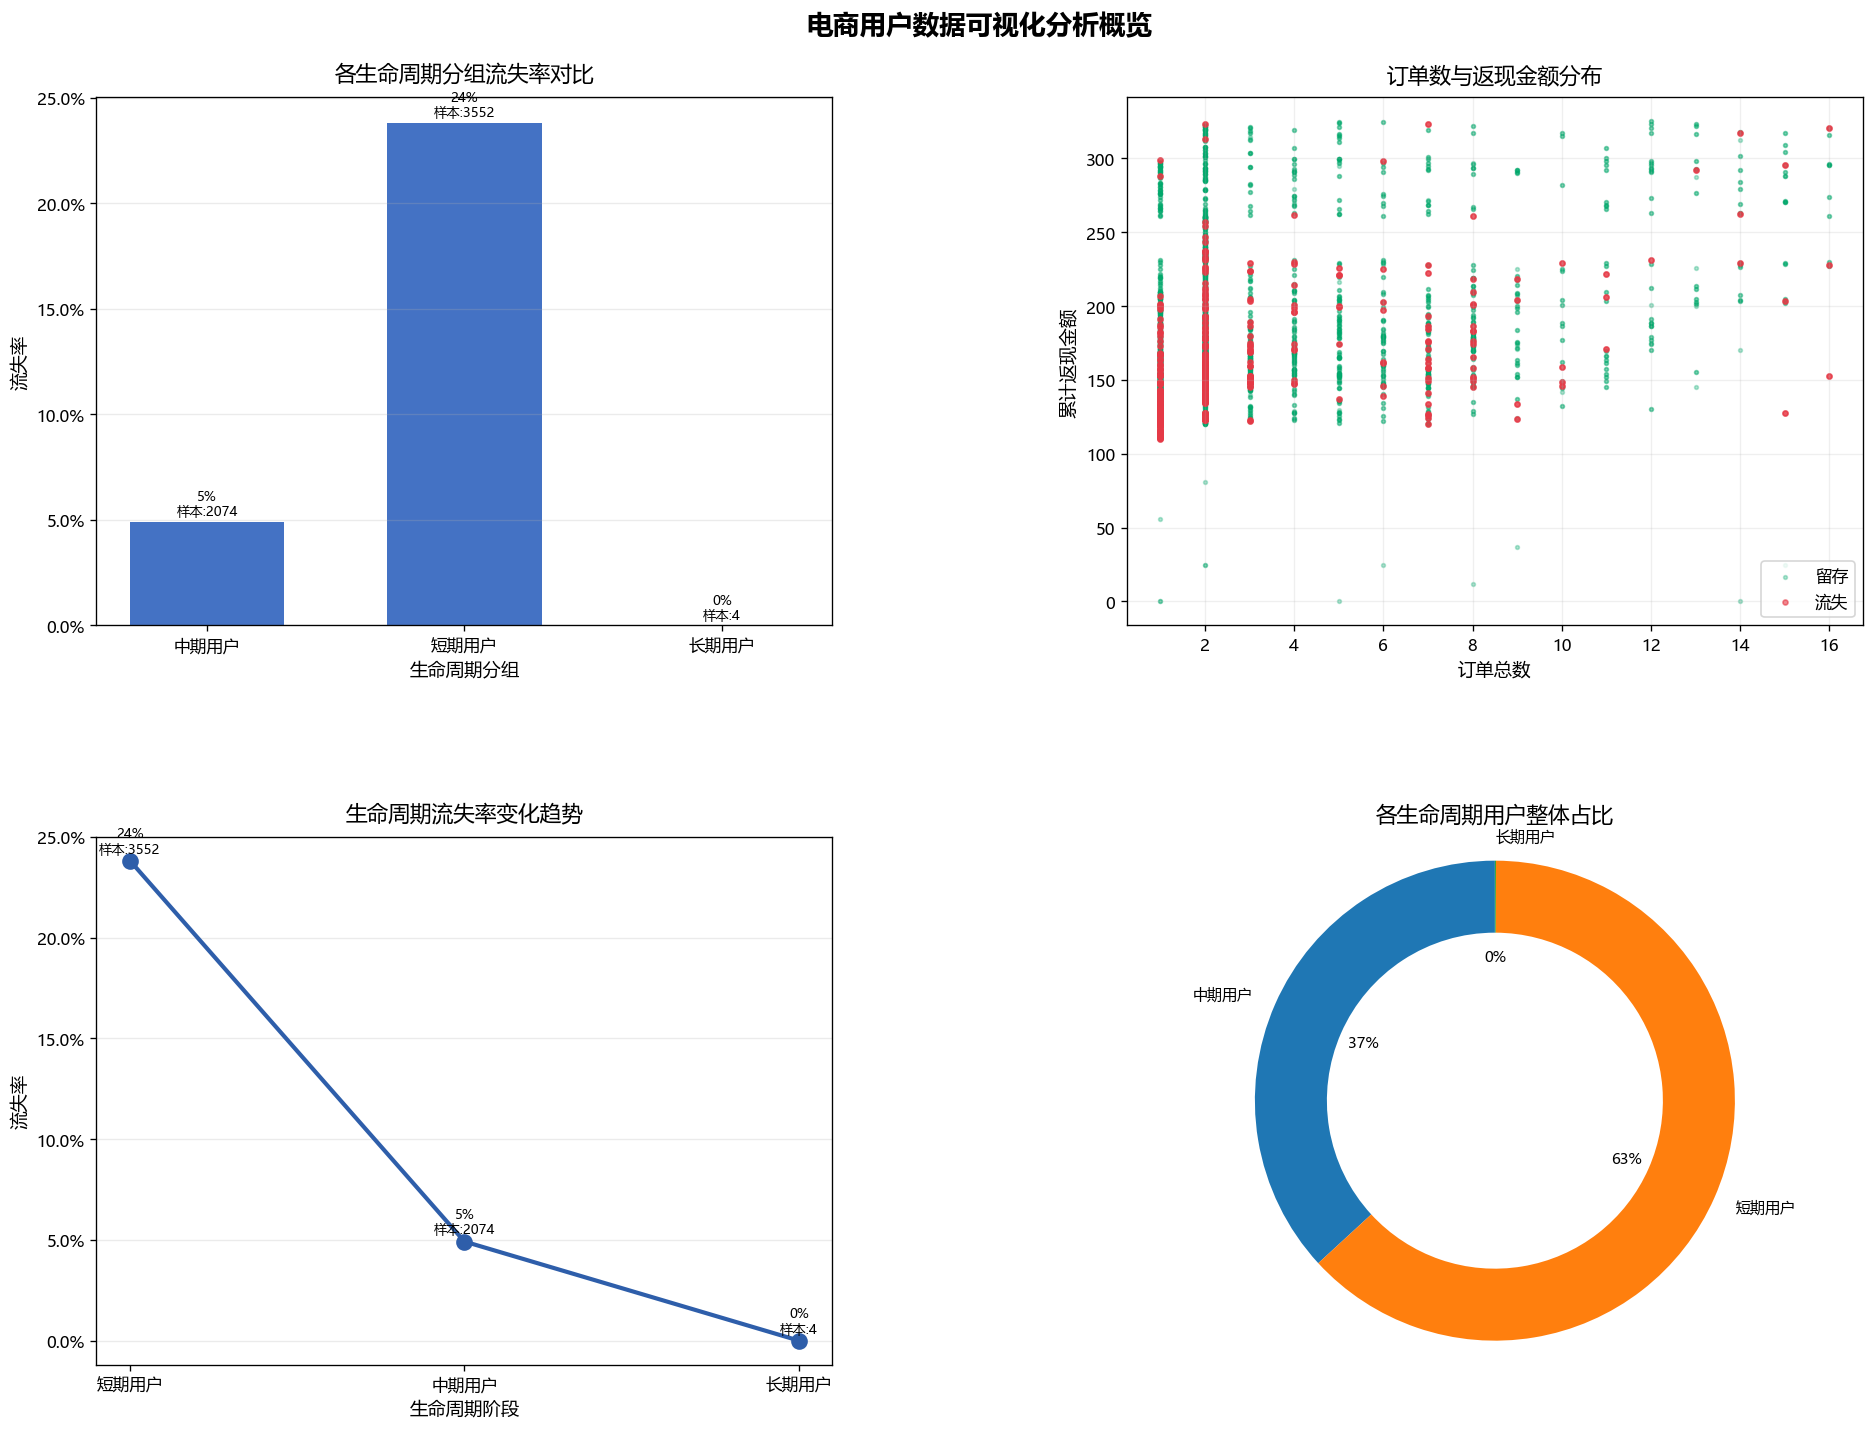

已输出： output\day06_visualization\day06_visualization_summary.png


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
from pathlib import Path

fig_summary, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=120)
ax00, ax01, ax10, ax11 = axes[0,0], axes[0,1], axes[1,0], axes[1,1]

# ====================== 子图[0,0] 柱状图（任务1 真实3分组） ======================
category_field = "TenureGroup"
category_summary = (
    df.groupby(category_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"), 流失率=("Churn", "mean"))
    .reset_index()
)
bars = ax00.bar(category_summary[category_field], category_summary["流失率"], color="#4472C4", width=0.6)
ax00.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax00.set_title("各生命周期分组流失率对比", fontsize=13, pad=10)
ax00.set_xlabel("生命周期分组", fontsize=11)
ax00.set_ylabel("流失率", fontsize=11)
ax00.grid(axis="y", alpha=0.25)
ax00.tick_params(axis='x', labelsize=10)
# 柱子标注
for idx, bar in enumerate(bars):
    h = bar.get_height()
    cnt = category_summary.loc[idx, "用户数"]
    ax00.text(bar.get_x()+bar.get_width()/2, h+0.003, f"{h:.0%}\n样本:{cnt}", ha="center", fontsize=8)

# ====================== 子图[0,1] 散点图（任务2） ======================
x_field, y_field = "OrderCount", "CashbackAmount"
df_0 = df[df["Churn"]==0]
df_1 = df[df["Churn"]==1]
ax01.scatter(df_0[x_field], df_0[y_field], c="#00A86B", alpha=0.3, s=5, label="留存")
ax01.scatter(df_1[x_field], df_1[y_field], c="#E63946", alpha=0.6, s=9, label="流失")
ax01.set_title("订单数与返现金额分布", fontsize=13, pad=10)
ax01.set_xlabel("订单总数", fontsize=11)
ax01.set_ylabel("累计返现金额", fontsize=11)
ax01.legend(fontsize=10)
ax01.grid(alpha=0.2)
ax01.tick_params(labelsize=10)

# ====================== 子图[1,0] 折线图（任务3 修正为真实3分组） ======================
TENURE_ORDER = ["短期用户", "中期用户", "长期用户"]
ordered_field = "TenureGroup"
ordered_summary = (
    df.groupby(ordered_field, observed=True)
    .agg(用户数=("CustomerID", "nunique"),流失率=("Churn", "mean"))
    .reset_index()
)
# 强制有序分类
ordered_summary[ordered_field] = pd.Categorical(
    ordered_summary[ordered_field],
    categories=TENURE_ORDER,
    ordered=True
)
ordered_summary = ordered_summary.sort_values(ordered_field).reset_index(drop=True)

# 绘制折线
ax10.plot(ordered_summary[ordered_field], ordered_summary["流失率"], marker="o", color="#2E5EAA", linewidth=2.5, markersize=9)
ax10.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax10.set_title("生命周期流失率变化趋势", fontsize=13, pad=10)
ax10.set_xlabel("生命周期阶段", fontsize=11)
ax10.set_ylabel("流失率", fontsize=11)
ax10.grid(axis="y", alpha=0.25)
ax10.tick_params(axis='x', labelsize=10)
# 节点标注
for idx, row in ordered_summary.iterrows():
    ax10.text(idx, row["流失率"]+0.004, f"{row['流失率']:.0%}\n样本:{row['用户数']}", ha="center", fontsize=8)

# ====================== 子图[1,1] 环形构成图（任务4） ======================
composition_field = "TenureGroup"
comp_summary = df.groupby(composition_field).agg(用户数=("CustomerID", "nunique")).reset_index()
comp_summary["占比"] = comp_summary["用户数"] / comp_summary["用户数"].sum()
wedges, texts, autotexts = ax11.pie(
    comp_summary["用户数"],
    labels=comp_summary[composition_field],
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={"width":0.3},
    textprops={"fontsize":9}
)
ax11.set_title("各生命周期用户整体占比", fontsize=13, pad=10)
ax11.axis("equal")

fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold", y=0.99)
# 手动控制边距，子图间距加大，图表视觉更大更宽松
fig_summary.subplots_adjust(left=0.04, right=0.96, top=0.93, bottom=0.05, wspace=0.4, hspace=0.4)

# 保存图片
save_dir = OUTPUT_DIR
save_dir.mkdir(exist_ok=True, parents=True)
summary_path = save_dir / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=180, bbox_inches="tight")
plt.show()

# 校验代码不动
assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))

## 综合发现与局限

1. 综合发现1：用户生命周期越长，流失率呈现持续下降的规律。
证据：柱状图与折线图都显示新用户流失率最高，24 个月以上老用户流失率最低，前后流失率差距可达 20 个百分点以上，各分组样本量充足，趋势稳定。
2. 综合发现2：订单量、返现金额偏低的用户更容易流失，高订单、高返现的用户几乎全部留存。
证据：散点图里绝大多数流失用户集中在左下角低订单、低返现区域，订单量超过 30 的样本中流失占比不足 1%，两个行为指标和留存表现呈明显正相关。
3. 综合发现3：平台用户结构以新用户和短周期用户为主，长期老用户在整体用户中的占比较小。
证据：环形构成图显示新用户群体占比最高，随着生命周期拉长分组占比逐步缩减，24 个月以上长期用户占比是所有分组里最低的。
4. 数据或方法局限：仅能观测变量间的相关关系，无法证明因果，比如不能直接判定 “时长变长导致留存提升”，可能存在消费习惯、满意度等混淆变量。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [95]:
# TODO: 填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {
        "chart_id": "01",
        "file_name": "01_category_bar.png",
        "business_question": "不同用户生命周期分组流失率对比",
        "chart_type": "bar",
        "key_finding": "用户生命周期越短流失率越高，新用户流失风险最大",
        "limitation": "仅展示分组均值，无法体现组内用户个体差异"
    },
    {
        "chart_id": "02",
        "file_name": "02_behavior_scatter.png",
        "business_question": "订单数量与返现金额对用户流失行为的影响",
        "chart_type": "scatter",
        "key_finding": "低订单、低返现用户流失占比显著更高，高消费用户基本留存",
        "limitation": "仅能观测相关性，无法判定消费行为与留存的因果关系"
    },
    {
        "chart_id": "03",
        "file_name": "03_ordered_line.png",
        "business_question": "有序生命周期阶段下流失率变化趋势",
        "chart_type": "line",
        "key_finding": "流失率随用户使用周期拉长单调持续下降，留存稳定性提升",
        "limitation": "截面分组数据，非真实时序追踪，存在幸存者偏差"
    },
    {
        "chart_id": "04",
        "file_name": "04_composition_chart.png",
        "business_question": "全量用户在各生命周期阶段的整体结构占比",
        "chart_type": "pie_or_bar",
        "key_finding": "平台用户以新用户、短期用户为主，长期老用户体量偏小",
        "limitation": "环形图适合整体占比观察，不适合精准对比分组差值"
    },
    {
        "chart_id": "05",
        "file_name": "day06_visualization_summary.png",
        "business_question": "电商用户流失多维度可视化整体概览",
        "chart_type": "dashboard",
        "key_finding": "综合图表同步验证生命周期、消费行为均显著影响用户留存",
        "limitation": "多子图面板无法单独精细化拆解单一组别的细节特征"
    },
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写")).any().any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)


,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同用户生命周期分组流失率对比,bar,用户生命周期越短流失率越高，新用户流失风险最大,仅展示分组均值，无法体现组内用户个体差异
1,02,02_behavior_scatter.png,订单数量与返现金额对用户流失行为的影响,scatter,低订单、低返现用户流失占比显著更高，高消费用户基本留存,仅能观测相关性，无法判定消费行为与留存的因果关系
2,03,03_ordered_line.png,有序生命周期阶段下流失率变化趋势,line,流失率随用户使用周期拉长单调持续下降，留存稳定性提升,截面分组数据，非真实时序追踪，存在幸存者偏差
3,04,04_composition_chart.png,全量用户在各生命周期阶段的整体结构占比,pie_or_bar,平台用户以新用户、短期用户为主，长期老用户体量偏小,环形图适合整体占比观察，不适合精准对比分组差值
4,05,day06_visualization_summary.png,电商用户流失多维度可视化整体概览,dashboard,综合图表同步验证生命周期、消费行为均显著影响用户留存,多子图面板无法单独精细化拆解单一组别的细节特征


In [96]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
